In [6]:
# Import libs
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [7]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller

# 1. Data Wrangling

In [32]:
### Read in CSV files (Core data files):

# us_csv = pd.read_csv("./Kaggle_data/USvideos.csv")
#       --------- OR ---------
url_data = "https://raw.githubusercontent.com/Thampi-hub/Springboard_RT/5ea29c1040625fc0ce6c182923120796e1f6ecd1/Cap3_AirPassengers/2_DataWrangling/Kaggle_data/AirPassengers.csv"
csv_data = pd.read_csv(url_data)

print("CSV dimensions: ", csv_data.shape,"\n")
print(csv_data.dtypes,"\n")
csv_data.head()

CSV dimensions:  (144, 2) 

Month          object
#Passengers     int64
dtype: object 



,Month,#Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [35]:
csv_data.rename(columns={'Month':'date', '#Passengers':'n_passengers'}, inplace=True)
csv_data.set_index('date', inplace=True)

# Set Frequency to avoid error when scoring ARIMA later
csv_data.index = pd.DatetimeIndex(csv_data.index.values, freq='MS')

csv_data.head()

,n_passengers
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


In [47]:
# Check if the file exists and remove it
filename = 'clean_passengers.pkl'
if os.path.isfile(filename):
    os.remove(filename)
csv_data.to_pickle(filename)


# If running on Google colab:
from google.colab import files
files.download(filename)


print(f"csv_data saved as '{filename}'")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

csv_data saved as 'clean_passengers.pkl'


# 2. Data Exploration

In [ ]:
# Read processed clean data (from GitHub):
filename = 'clean_passengers.pkl'
if os.path.isfile(filename):
    os.remove(filename)

!wget https://raw.githubusercontent.com/Thampi-hub/Springboard_RT/refs/heads/main/Cap3_YouTube/2_DataWrangling/clean_data.pkl
filtrData = pd.read_pickle(filename)

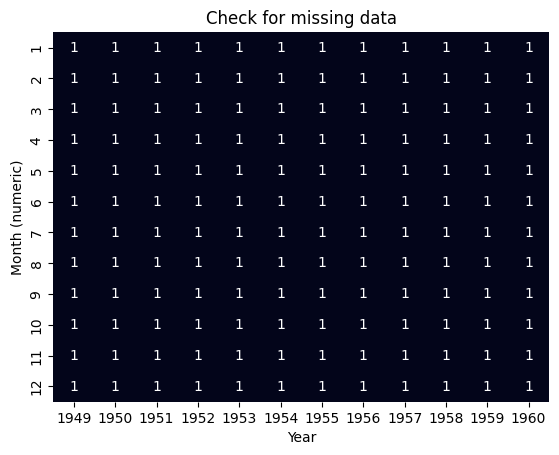

In [36]:
heat_dt1 = csv_data.copy().reset_index(names="date")
heat_dt1["status"] = heat_dt1['n_passengers'].apply(lambda x: 1 if x>0 and x is not None else 0)
heat_dt1["month"]  = heat_dt1['date'].dt.month
heat_dt1["year"]   = heat_dt1['date'].dt.year

heat_dt2 = pd.DataFrame(heat_dt1, columns=['status','month','year']).set_index(['month','year']).\
            pivot_table(index='month', columns='year', values='status')

# heat_dt2.iloc[0,4] = 0
sns.heatmap(heat_dt2, annot=True, cbar=False)
plt. title("Check for missing data")
plt.xlabel("Year")
plt.ylabel("Month (numeric)")
plt.show()

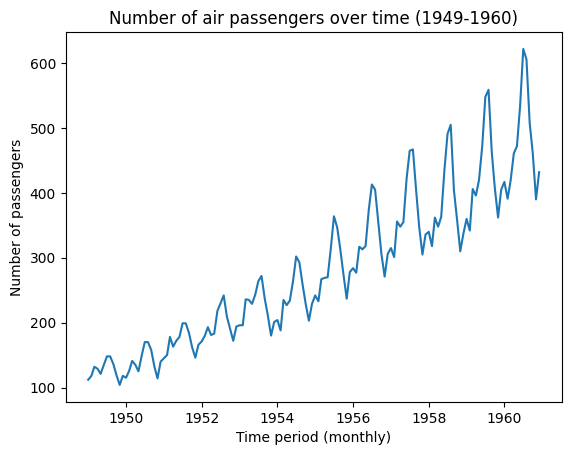

In [26]:
sns.lineplot(data=csv_data, x=csv_data.index, y="n_passengers")
plt.xlabel("Time period (monthly)")
plt.ylabel("Number of passengers")
plt.title("Number of air passengers over time (1949-1960)")
plt.show()

No outiers are seen in the time series.
Seasonality is evident in the trend (on a yearly basis), with an upward growing trend. The data is in definite need for differencing

<Figure size 1000x700 with 0 Axes>

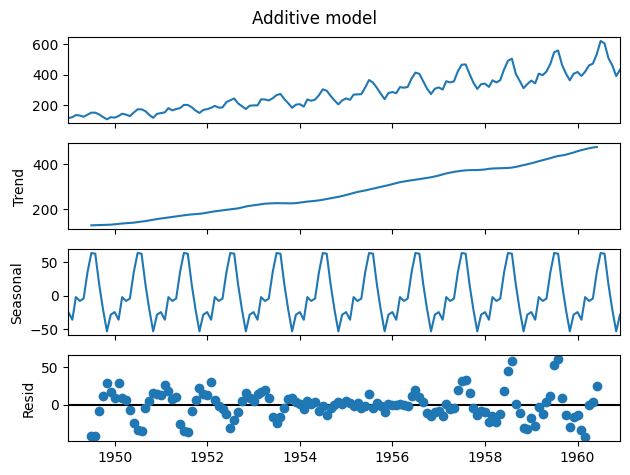

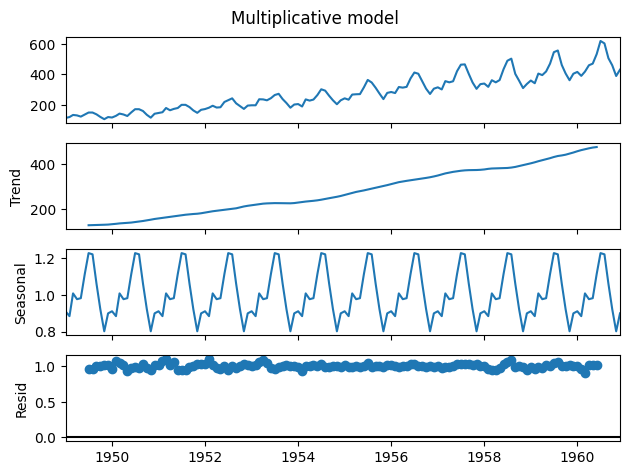

In [12]:
from statsmodels.tsa.seasonal import seasonal_decompose
plt.figure(figsize=(10, 7))
decomp1 = seasonal_decompose(csv_data['n_passengers'], period=12, model='additive')
add_fig = decomp1.plot()
for ax in add_fig.axes:
    ax.set_title("")
add_fig.suptitle("Additive model")
plt.xlabel("")
plt.show()

decomp2 = seasonal_decompose(csv_data['n_passengers'], period=12, model='multiplicative')
mul_fig = decomp2.plot()
for ax in mul_fig.axes:
    ax.set_title("")
mul_fig.suptitle("Multiplicative model")
plt.show()

The additive models still leaves behind some trends in the residuals after decomposition. Thus **multiplicative model** was chosen for decomposition!

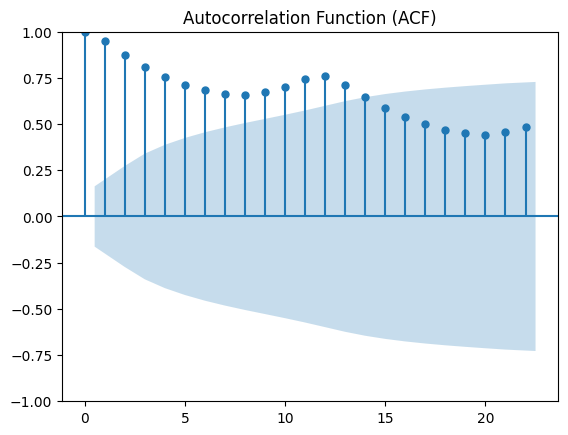

In [27]:
plot_acf(csv_data)
plt.title("Autocorrelation Function (ACF)")
plt.show()

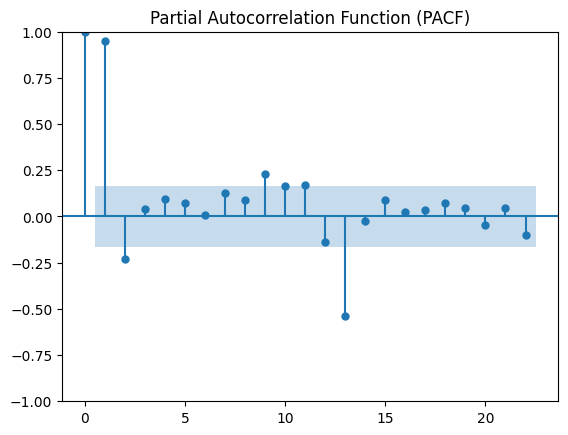

In [28]:
plot_pacf(csv_data)
plt.title("Partial Autocorrelation Function (PACF)")
plt.show()

# 3. Modelling

In [37]:
import warnings
from sklearn.metrics import mean_squared_error


In [38]:
# Split data for Training & Testing:

Split_percentage = 0.7
split_at_n = int(np.floor(Split_percentage * csv_data.shape[0]))

train, test = csv_data[:split_at_n], csv_data[split_at_n:]

## 3.1 ARIMA

In [17]:
warnings.filterwarnings("error", category=UserWarning)  # Convert UserWarning into an exception
def evaluate_arima(dt, arima_order):
  try:
    arima = ARIMA(dt, order = arima_order, freq="MS")
    arima_fit  = arima.fit()
    # res = arima_fit.aic
    res = mean_squared_error(test, arima_fit.forecast(steps=len(test)) )
  except:
    res = np.inf
  return res

# evaluate_arima(train, (0, 0, 2))
score_list = []
order_list = []
for p in range(4):
  for d in range(4):
    for q in range(4):
      aic_result = round(evaluate_arima(train, (p, d, q)), 3);
      if aic_result != np.inf:
        score_list.append(aic_result)
        order_list.append((p, d, q))
        print(f"ARIMA({p}, {d}, {q}) = {aic_result}")

warnings.resetwarnings()

ARIMA(0, 0, 0) = 46934.672
ARIMA(0, 0, 2) = 46715.639
ARIMA(0, 1, 0) = 11183.023
ARIMA(0, 1, 1) = 12631.693
ARIMA(0, 1, 2) = 13852.273
ARIMA(0, 1, 3) = 14778.645
ARIMA(0, 2, 0) = 87728.477
ARIMA(0, 2, 1) = 4895.142
ARIMA(0, 2, 2) = 5547.713
ARIMA(0, 2, 3) = 6062.88
ARIMA(0, 3, 0) = 847875904.932
ARIMA(0, 3, 1) = 129132.375
ARIMA(0, 3, 3) = 4957.528
ARIMA(1, 0, 0) = 28441.719
ARIMA(1, 0, 1) = 37868.747
ARIMA(1, 0, 2) = 30727.142
ARIMA(1, 0, 3) = 20013.096
ARIMA(1, 1, 0) = 11508.793
ARIMA(1, 1, 1) = 12460.364
ARIMA(1, 1, 2) = 14889.769
ARIMA(1, 1, 3) = 14864.504
ARIMA(1, 2, 0) = 8718.748
ARIMA(1, 2, 1) = 5039.615
ARIMA(1, 2, 2) = 5394.632
ARIMA(1, 2, 3) = 5395.779
ARIMA(1, 3, 0) = 65579715.338
ARIMA(1, 3, 1) = 6632.79
ARIMA(1, 3, 3) = 4534.78
ARIMA(2, 0, 0) = 36372.379
ARIMA(2, 0, 1) = 33830.631
ARIMA(2, 0, 3) = 19163.92
ARIMA(2, 1, 0) = 13208.005
ARIMA(2, 1, 1) = 14485.619
ARIMA(2, 1, 2) = 14560.845
ARIMA(2, 2, 0) = 4701.494
ARIMA(2, 2, 1) = 5778.843
ARIMA(2, 2, 2) = 5379.311
ARIMA(2, 2

In [41]:
# !pip install pmdarima
# import pmdarima

# # Fit Auto ARIMA to find optimal p, d, q
# auto_model = auto_arima(train['n_passengers'], m=12, seasonal=True, stepwise=False, trace=True)

# # Print optimal parameters
# print(auto_model.summary())


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 56.7 MB/s eta 0:00:00


<frozen importlib._bootstrap>:1047: ImportWarning: _PyDriveImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bootstrap>:1047: ImportWarning: _BokehImportHook.find_spec() not found; falling back to find_module()
/usr/local/lib/python3.11/dist-packages/google/colab/_pip.py:86: ResourceWarning: unclosed file <_io.TextIOWrapper name='/usr/local/lib/python3.11/dist-packages/pmdarima-2.0.4.dist-info/top_level.txt' mode='r' encoding='utf-8'>
  for line in open(toplevel):


ValueError: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject

In [42]:
summary_dict = dict(zip(order_list, score_list))

min_value = min(summary_dict.values())
best_arima_order, best_arima_score = [(key,value) for key, value in summary_dict.items() if value == min_value][0]

print(f"Best ARIMA params (p, d, q) = {best_arima_order}. \nScore = {best_arima_order}")

Best ARIMA params (p, d, q) = (2, 3, 1). 
Score = (2, 3, 1)


In [43]:
# Fit ARIMA model (p, d, q) parameters
model = ARIMA(train, order = best_arima_order)
model_fit = model.fit()

# Print summary of the model
print(model_fit.summary())

# Forecast next 10 steps
predicted = pd.DataFrame({"n_passengers" : model_fit.forecast(steps=len(test))},
                         index = test.index)
# print("Forecast:", predicted)
# predicted.index


                               SARIMAX Results                                
Dep. Variable:           n_passengers   No. Observations:                  100
Model:                 ARIMA(2, 3, 1)   Log Likelihood                -460.326
Date:                Fri, 16 May 2025   AIC                            928.652
Time:                        02:33:31   BIC                            938.951
Sample:                    01-01-1949   HQIC                           932.817
                         - 04-01-1957                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3461      0.106     -3.262      0.001      -0.554      -0.138
ar.L2         -0.3371      0.121     -2.793      0.005      -0.574      -0.101
ma.L1         -0.9990      2.415     -0.414      0.6

(144, 1)
(144, 1)


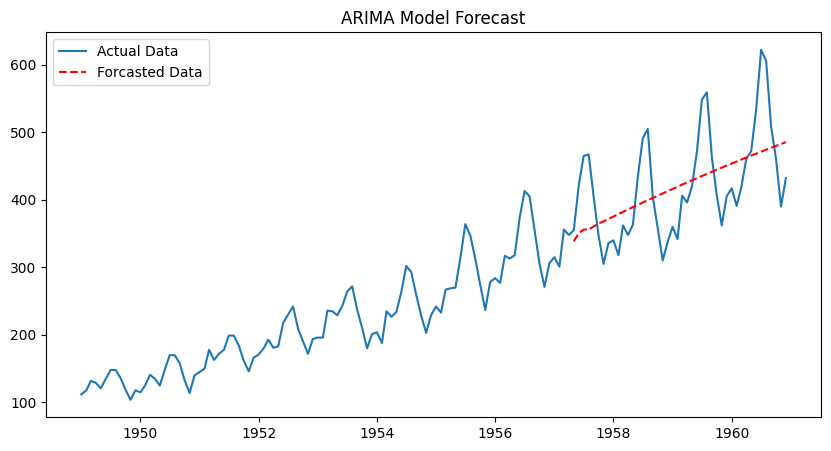

In [44]:
forecast_dt = pd.concat([train, predicted])
original_data = csv_data.copy()

print(forecast_dt.shape)
print(original_data.shape)

# Plot actual vs forecasted values
plt.figure(figsize=(10, 5))
plt.plot(original_data.index, original_data["n_passengers"], label="Actual Data")
plt.plot(predicted.index, predicted["n_passengers"], label="Forcasted Data", linestyle="dashed", color="red")
plt.legend()
plt.title("ARIMA Model Forecast")
plt.show()